# Plotting streaming data

HyperTools treats *data streams* as just another supported data type: pass any
Python iterator/generator, or a [Hugging Face streaming
dataset](https://huggingface.co/docs/datasets/en/stream)
(`load_dataset(..., streaming=True)`), directly to `hyp.plot` -- no special
flag needed.

How it works (see
[issue #101](https://github.com/ContextLab/hypertools/issues/101)):

1. the first `stream_init` samples (default 10,000) are used to *estimate*
   the normalization and dimensionality-reduction parameters;
2. those fitted models are then *applied* to every subsequent sample, which
   is added to the plot dynamically as it arrives;
3. streaming continues until the stream is exhausted, `stream_max` samples
   have been consumed, or you interrupt with Ctrl-C. Infinite streams render
   continually -- and if you're saving an animation with `save_path`, the
   file is finalized whenever streaming stops (including on interrupt).

Because new samples are projected with models fitted on the head of the
stream, the reduction model must support `transform()` (e.g. the default
`IncrementalPCA`, or `PCA`/`UMAP` -- but not `TSNE`).

In [1]:
import numpy as np
import hypertools as hyp

%matplotlib inline

## Streaming from a generator

Here's a simulated live data feed: a Lorenz attractor unfolding in a
10-dimensional embedding, written as an *infinite* generator. `hyp.plot`
detects that it's a stream, fits `IncrementalPCA` on the first 500 samples,
then projects each new chunk of 100 samples through that fitted model and
adds it to the plot. `stream_max` cuts the (infinite) stream off so the
animation can be saved.

In [2]:
def live_feed(dt=0.01, dim=10, seed=42):
    """An infinite stream: Lorenz dynamics embedded in `dim` dimensions."""
    rng = np.random.default_rng(seed)
    W = rng.standard_normal((3, dim))
    xyz = np.array([1., 1., 1.])
    while True:
        x, y, z = xyz
        xyz = xyz + dt * np.array([10 * (y - x),
                                   x * (28 - z) - y,
                                   x * y - 8 / 3 * z])
        yield xyz @ W + 0.05 * rng.standard_normal(dim)


geo = hyp.plot(live_feed(), stream_init=500, stream_chunk=100,
               stream_max=3000, save_path='streaming_lorenz.gif',
               show=False)
geo.stream_info['n_samples'], geo.xform_data[0].shape

(3000, (3000, 3))

![streaming lorenz](streaming_lorenz.gif)

Each animation frame corresponds to one fetched chunk, so `stream_chunk`
sets both the download batch size and the temporal resolution of the saved
animation.

The returned `DataGeometry` retains everything that was consumed:
`geo.data` holds the raw samples, `geo.xform_data` the projected trajectory,
and `geo.stream_info` records the fitted reduction model and whether the
stream was cut off (`truncated=True` means there was more data left).

In [3]:
{k: (type(v).__name__ if k == 'reduce_model' else v)
 for k, v in geo.stream_info.items()}

{'n_samples': 3000, 'reduce_model': 'IncrementalPCA', 'truncated': True}

## Comet-style display with `stream_window`

For long (or infinite) streams the accumulated trajectory can get dense.
Passing `stream_window` displays only the most recent samples -- older
points scroll off comet-style -- while everything consumed is still
retained on the returned geometry.

In [4]:
geo = hyp.plot(live_feed(seed=7), stream_init=500, stream_chunk=100,
               stream_max=3000, stream_window=750,
               save_path='streaming_window.gif', show=False)
len(geo.ax.lines[0].get_data_3d()[0]), geo.xform_data[0].shape[0]

(750, 3000)

![streaming window](streaming_window.gif)

## Streaming a Hugging Face dataset

Any `datasets.IterableDataset` streams straight into `hyp.plot` without
downloading the full dataset first. Rows arrive as dicts; numeric fields
are extracted (in order) and concatenated into one vector per sample, and
non-numeric fields are ignored -- use `.select_columns(...)` to control
exactly which features are used.

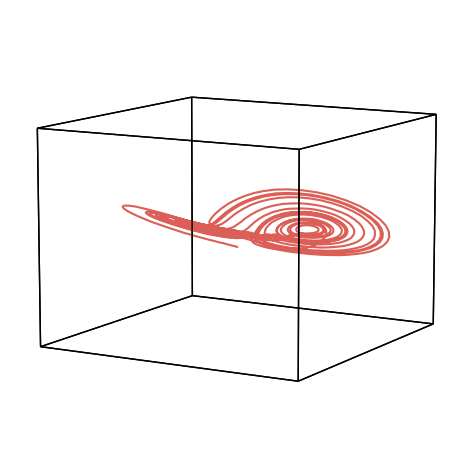

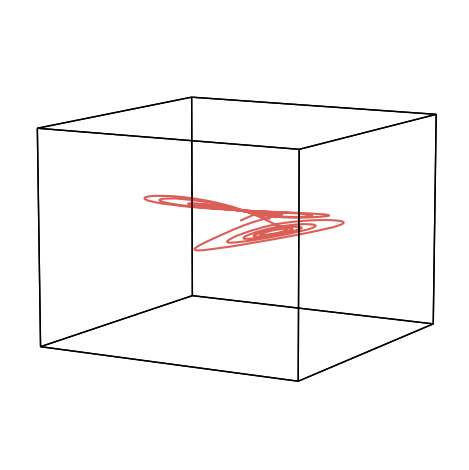

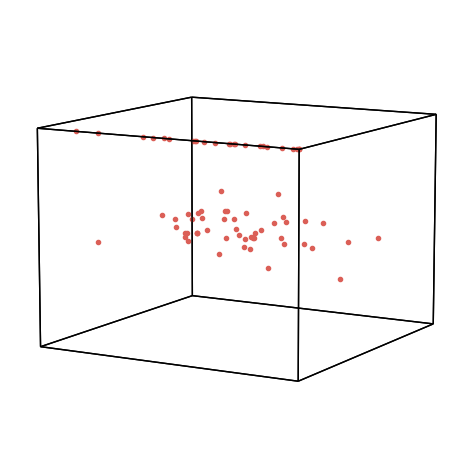

(150, (150, 4))

In [5]:
from datasets import load_dataset

ds = load_dataset('scikit-learn/iris', split='train', streaming=True)
ds = ds.select_columns(['SepalLengthCm', 'SepalWidthCm',
                        'PetalLengthCm', 'PetalWidthCm'])

geo = hyp.plot(ds, '.', markersize=6, stream_init=50, stream_chunk=25)
geo.stream_info['n_samples'], geo.data[0].shape

The four numeric iris measurements stream through the
model fitted on the first 50 flowers and land in a 3-dimensional embedding,
50 → 150 samples, without the dataset ever being materialized locally.

A few practical notes:

- with the default `stream_max=None`, plotting an infinite stream runs
  until you interrupt it (Ctrl-C) -- the plot keeps updating live, and any
  `save_path` animation is finalized on interrupt;
- `align` and `cluster` aren't yet supported for streams (a stream is a
  single dataset, and clustering streams is planned for a future release);
- everything consumed is kept in memory on the returned geometry, so very
  long-running streams should budget accordingly.